## 01_line_chart_styles

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### анализируйте только пользователей, а не администраторов

In [2]:
pageviews = pd.read_sql(
    """
        SELECT datetime
        FROM pageviews
        WHERE uid LIKE 'user_%'
    """,
    conn,
    parse_dates="datetime",
)
pageviews

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


In [3]:
checker = pd.read_sql(
    """
        SELECT timestamp
        FROM checker
        WHERE uid LIKE 'user_%'
    """,
    conn,
    parse_dates="timestamp",
)
checker

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


### анализируйте только даты, когда были как просмотры, так и проверки

In [4]:
pageviews["view_date"] = pageviews.datetime.dt.date
view_dates = pageviews.groupby(
    pageviews.view_date, as_index=False
).view_date.value_counts()
view_dates

,view_date,count
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


In [5]:
checker["commit_date"] = checker.timestamp.dt.date
commit_dates = checker.groupby(
    checker.commit_date, as_index=False
).commit_date.value_counts()
commit_dates

,commit_date,count
0,2020-04-17,23
1,2020-04-18,69
2,2020-04-19,33
3,2020-04-20,25
4,2020-04-21,25
5,2020-04-22,28
6,2020-04-23,43
7,2020-04-24,16
8,2020-04-25,104
9,2020-04-26,261


In [6]:
df = pd.merge(
    left=commit_dates, right=view_dates, left_on="commit_date", right_on="view_date"
)
df.rename(
    columns={"count_x": "commits", "count_y": "views", "commit_date": "date"},
    inplace=True,
)
df.drop(columns="view_date", inplace=True)
df.date = pd.to_datetime(df.date)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     32 non-null     datetime64[ns]
 1   commits  32 non-null     int64         
 2   views    32 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 900.0 bytes


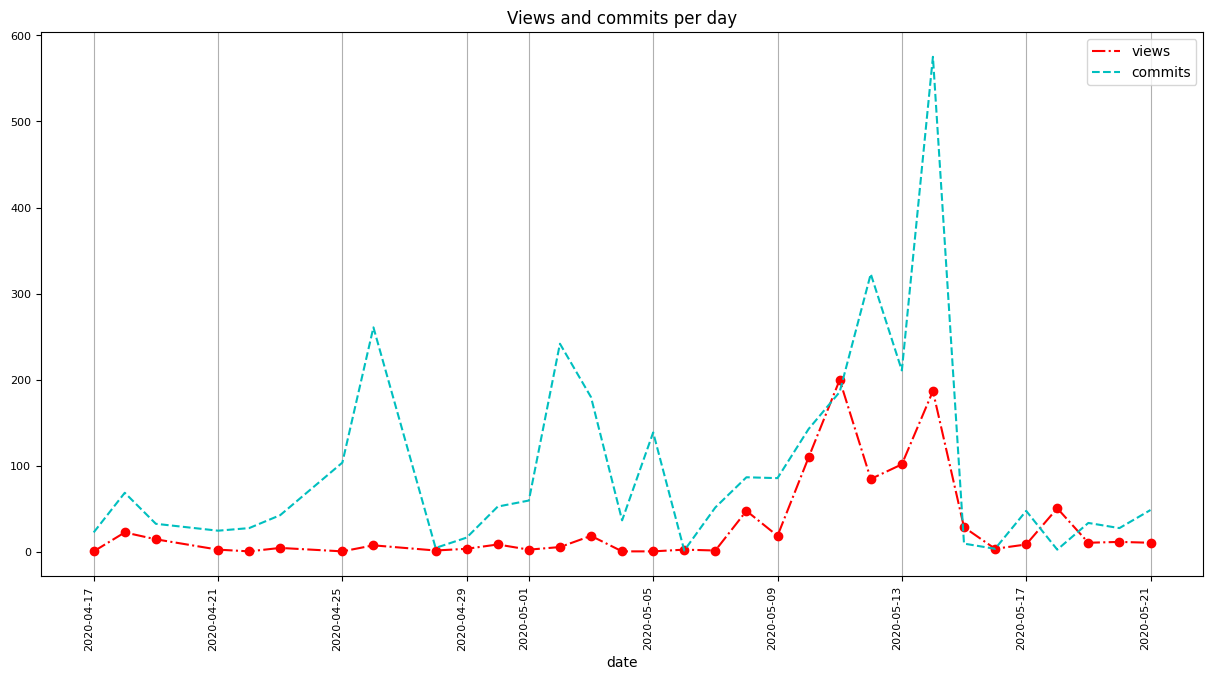

In [7]:
graf = df.plot(
    x="date",
    y=["views", "commits"],
    figsize=(15, 8),
    fontsize=8,
    title="Views and commits per day",
    rot=90,
    style=["-.", "--"],
    color=["r", "c"],
)
graf.get_lines()[0].set_marker("o")
graf.grid(axis="x")

In [8]:
(df.views > 150).sum()

np.int64(2)

### Сколько раз количество просмотров превышало 150? Ответ — 2.

In [9]:
conn.close()